In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr
import smarts_cerebellum.globals as gl

In [2]:
cst = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', 'summary_MNISymC_CST_WM_mod.tsv'), sep = '\t')
cst['hemisphere'] = cst.regionname.str[0].astype(str).str.upper()
cst = cst[cst.isPatient == 1] # just patients


regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
cerebel = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
cerebel = cerebel[cerebel.isPatient==1] # just patients
cerebel = cerebel[cerebel.regionname.isin(regions)]
cerebel['hemisphere'] = cerebel.regionname.str[2]


behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t') # only paretic hand
# behavioural data copied from smarts/bedside/analysis/

# make subj_id column consistent
behav['subj_id'] = behav['subj_name'].str.strip()
behav.loc[behav['week']==1, 'week'] = 0
behav.rename(columns = {'week': 'Week'}, inplace = True)


# NORMALISE AFFECTED VOLUME BY UNAFFECTED VOLUME - CST (affected = ipsi i.e. right)
cst['regionname_bilat'] = cst.regionname.str[-3:]
left_cst = cst[cst.hemisphere == 'L'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'left_mean'})
right_cst = cst[cst.hemisphere == 'R'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'right_mean'})
norm_cst = left_cst.merge(right_cst, on = ['subj_id', 'Week', 'regionname_bilat'], suffixes = ('_left', '_right'))

# normalise contralesional (affected) side by unaffected side; analogous to Jing's behav norm
norm_cst['right_norm'] = norm_cst['right_mean']/norm_cst['left_mean']



# NORMALISE AFFECTED VOLUME BY UNAFFECTED VOLUME - CEREBELLUM (affected - contra i.e. left)
cerebel['regionname_bilat'] = cerebel.regionname.str[:2]
left_cerebel = cerebel[cerebel.hemisphere == 'L'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'left_mean'})
right_cerebel = cerebel[cerebel.hemisphere == 'R'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'right_mean'})
norm_cerebel = left_cerebel.merge(right_cerebel, on = ['subj_id', 'Week', 'regionname_bilat'], suffixes = ('_left', '_right'))

norm_cerebel['left_norm'] = norm_cerebel['left_mean']/norm_cerebel['right_mean']

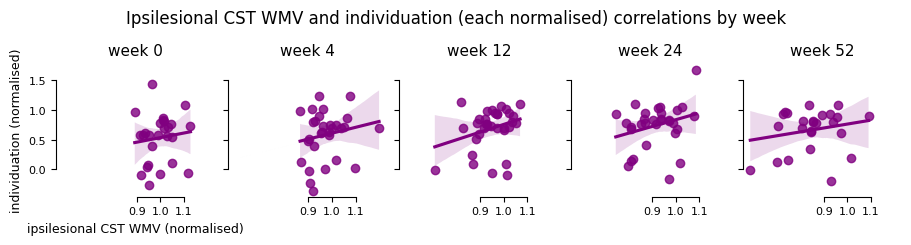

In [ ]:
# affected: ipsilesional CST, paretic hand
weeks = [0, 4, 12, 24, 52]

fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(weeks):
    behav_plot = behav[behav.Week == week]
    ipsi_cst = norm_cst[(norm_cst.Week == week)] # all lesions (mirrored to) right hemisphere
    ipsi_cst_indiv = pd.merge(ipsi_cst, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cst', '_behav'))

    ax = axs[i]
    #sns.scatterplot(x = 'right_norm', y = 'indiv_norm', data =aff_df, ax = ax, edgecolor = None,  legend = False)
    sns.regplot(x = 'right_norm', y = 'indiv_norm', data = ipsi_cst_indiv, ax = ax, color = 'purple')
    sns.despine(trim = True)

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("ipsilesional CST WMV (normalised)")

fig.suptitle(f"Ipsilesional CST WMV and individuation (each normalised) correlations by week", y = 1.15)
plt.show()


In [36]:
print("**Pearson R and p-value for ipsilesional CST and individuation** \n")
for week in weeks:
    behav_plot = behav[behav.Week == week]
    ipsi_cst = norm_cst[(norm_cst.Week == week)] # all lesions (mirrored to) right hemisphere
    ipsi_cst_indiv = pd.merge(ipsi_cst, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cst', '_behav'))

    r_stat, p_stat = pearsonr(ipsi_cst_indiv['right_norm'], ipsi_cst_indiv['indiv_norm'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for ipsilesional CST and individuation** 

week 0: r = 0.11835079134577642, p-value = 0.5647345194718202
week 4: r = 0.180930982477657, p-value = 0.33865859303049833
week 12: r = 0.29103588439250166, p-value = 0.10034162747129959
week 24: r = 0.2741516348343177, p-value = 0.13558151702949406
week 52: r = 0.21242146768291503, p-value = 0.30800088853227037


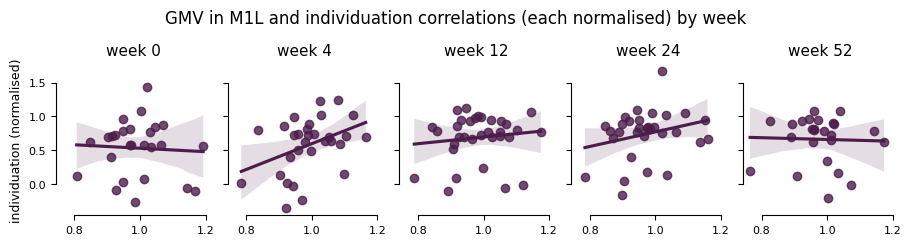

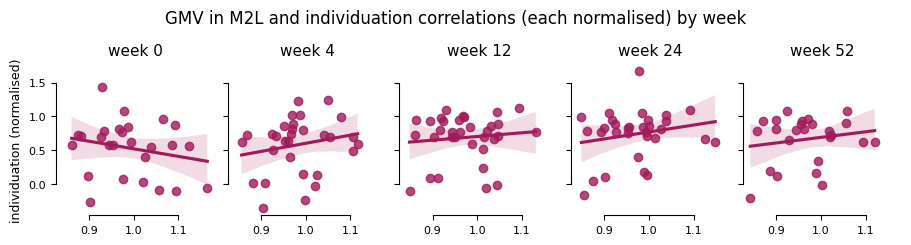

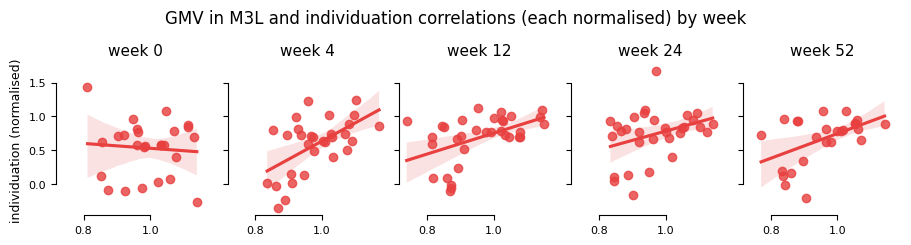

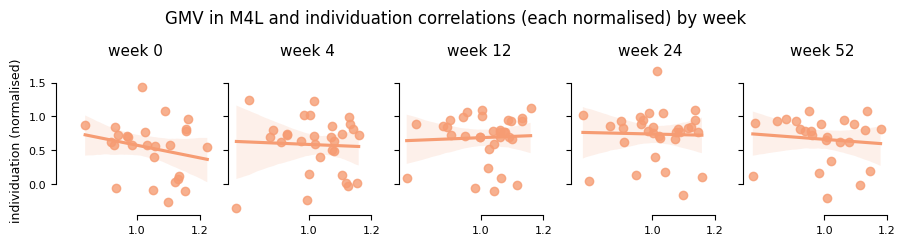

In [34]:
# affected: contralesional cerebellum, paretic hand
weeks = [0, 4, 12, 24, 52]
colors = sns.color_palette('rocket', n_colors = 4)

for r, region in enumerate(regions[:4]): # left ROIs
    fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
    for i, week in enumerate(weeks):
        behav_plot = behav[behav.Week == week]
        contra_cerebel = norm_cerebel[(norm_cerebel.Week == week)]# & (cerebel.regionname == cerebellar_region)]
        contra_cerebel_indiv = pd.merge(contra_cerebel, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cerebel', '_behav'))

        ax = axs[i]
        sns.regplot(x = 'left_norm', y = 'indiv_norm', data = contra_cerebel_indiv[contra_cerebel_indiv.regionname_left == region], ax = ax, color = colors[r])
        sns.despine(trim = True)

        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_title(f'week {week}')
        
    axs[0].set_ylabel("individuation (normalised)")
    fig.suptitle(f'GMV in {region} and individuation correlations (each normalised) by week', y = 1.15)
    plt.show()


In [48]:
for region in regions[:4]:
    print(f'Cerebellar region {region}')
    for week in weeks:
        behav_plot = behav[behav.Week == week]
        contra_cerebel = norm_cerebel[(norm_cerebel.Week == week) & (norm_cerebel.regionname_left == region)]
        contra_cerebel_indiv = pd.merge(contra_cerebel, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cerebel', '_behav'))
        
        r_stat, p_stat = pearsonr(contra_cerebel_indiv['left_norm'], contra_cerebel_indiv['indiv_norm'])
        print(f'week {week}: r = {r_stat}, p-value = {p_stat}')
    print('\n')

Cerebellar region M1L
week 0: r = -0.0565846436700599, p-value = 0.7836573724521834
week 4: r = 0.39303483614881135, p-value = 0.03166742501098606
week 12: r = 0.1272709463796431, p-value = 0.4803103088366598
week 24: r = 0.2596953837523268, p-value = 0.15829052705708554
week 52: r = -0.03207463905521027, p-value = 0.8790280620582807


Cerebellar region M2L
week 0: r = -0.22253058515373098, p-value = 0.27454518286766294
week 4: r = 0.20291099425723483, p-value = 0.28219512224068355
week 12: r = 0.10967362152918622, p-value = 0.5434717019951438
week 24: r = 0.20682102103888675, p-value = 0.2642798446265478
week 52: r = 0.1704345963272298, p-value = 0.41534137887268274


Cerebellar region M3L
week 0: r = -0.07941815007852243, p-value = 0.6997568859712523
week 4: r = 0.5666395768217282, p-value = 0.001096292005569815
week 12: r = 0.4857307553122437, p-value = 0.004162083768635509
week 24: r = 0.3411549991707901, p-value = 0.060353280441887924
week 52: r = 0.4932989516479676, p-value = 0.0

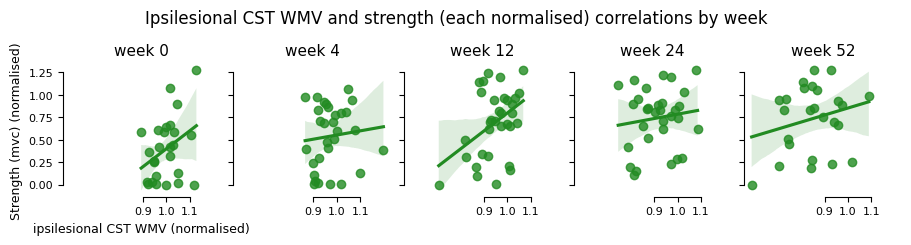

In [32]:
# affected: ipsilesional CST, paretic hand
weeks = [0, 4, 12, 24, 52]

fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(weeks):
    behav_plot = behav[behav.Week == week]
    ipsi_cst = norm_cst[(norm_cst.Week == week)] # all lesions (mirrored to) right hemisphere
    ipsi_cst_mvc = pd.merge(ipsi_cst, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cst', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'right_norm', y = 'mvc_norm', data = ipsi_cst_mvc, ax = ax, color = 'forestgreen')
    sns.despine(trim = True)

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("Strength (mvc) (normalised)")
axs[0].set_xlabel("ipsilesional CST WMV (normalised)")

fig.suptitle(f"Ipsilesional CST WMV and strength (each normalised) correlations by week", y = 1.15)
plt.show()


In [37]:
print("**Pearson R and p-value for ipsilesional CST and individuation** \n")
for week in weeks:
    behav_plot = behav[behav.Week == week]
    ipsi_cst = norm_cst[(norm_cst.Week == week)] # all lesions (mirrored to) right hemisphere
    ipsi_cst_mvc = pd.merge(ipsi_cst, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cst', '_behav'))

    r_stat, p_stat = pearsonr(ipsi_cst_mvc['right_norm'], ipsi_cst_mvc['mvc_norm'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for ipsilesional CST and individuation** 

week 0: r = 0.3620456627435928, p-value = 0.06913926492273244
week 4: r = 0.09933829022246146, p-value = 0.6014799117499574
week 12: r = 0.4171980821415734, p-value = 0.015713058172754986
week 24: r = 0.1296179618628991, p-value = 0.4870767573382682
week 52: r = 0.23901381917639514, p-value = 0.249872257705878


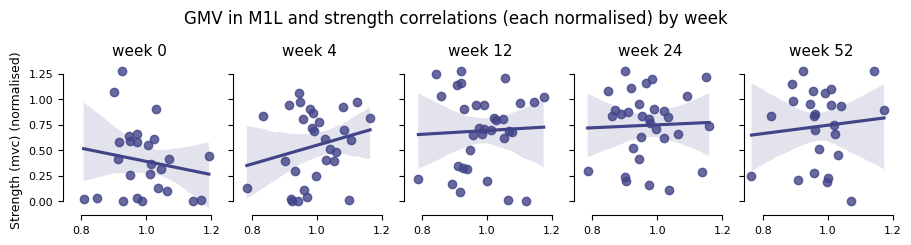

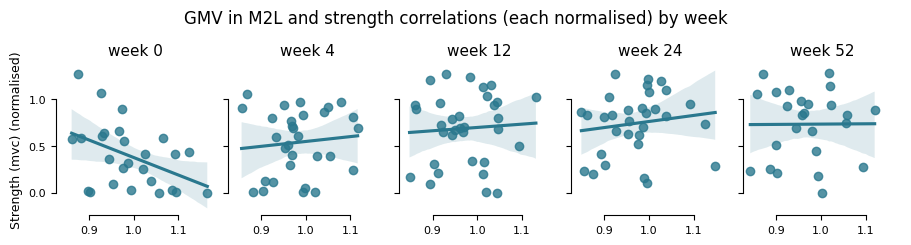

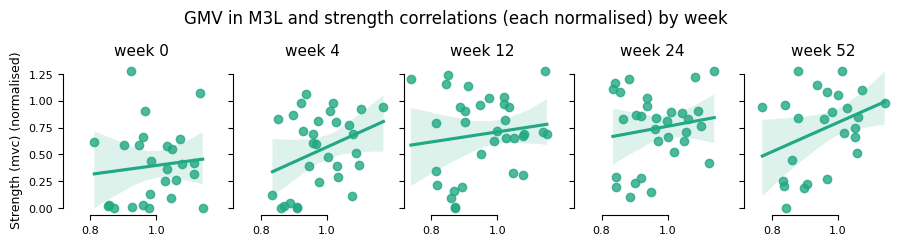

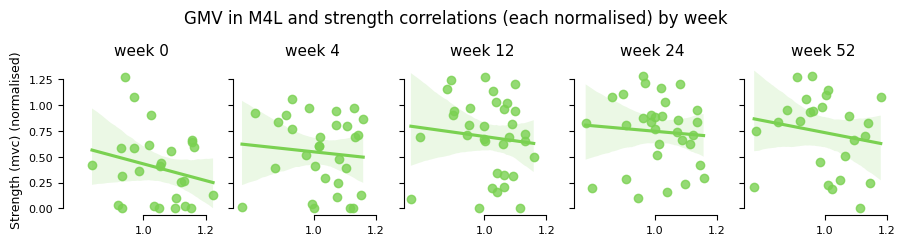

In [33]:
# affected: contralesional cerebellum, paretic hand
weeks = [0, 4, 12, 24, 52]
colors = sns.color_palette('viridis', n_colors = 4)

for r, region in enumerate(regions[:4]): # left ROIs
    fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
    for i, week in enumerate(weeks):
        behav_plot = behav[behav.Week == week]
        contra_cerebel = norm_cerebel[(norm_cerebel.Week == week)]# & (cerebel.regionname == cerebellar_region)]
        #contra_cerebel = cerebel[(cerebel.hemisphere == 'L') & (cerebel.Week == week)]# & (cerebel.regionname == cerebellar_region)] # all lesions (mirrored to) right hemisphere
        contra_cerebel_mvc = pd.merge(contra_cerebel, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cerebel', '_behav'))

        ax = axs[i]
        sns.regplot(x = 'left_norm', y = 'mvc_norm', data = contra_cerebel_mvc[contra_cerebel_mvc.regionname_left == region], ax = ax, color = colors[r])
        sns.despine(trim = True)

        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_title(f'week {week}')
        
    axs[0].set_ylabel("Strength (mvc) (normalised)")
    fig.suptitle(f'GMV in {region} and strength correlations (each normalised) by week', y = 1.15)
    plt.show()

In [52]:
for region in regions[:4]:
    print(f'Cerebellar region {region}')
    for week in weeks:
        behav_plot = behav[behav.Week == week]
        contra_cerebel = norm_cerebel[(norm_cerebel.Week == week) & (norm_cerebel.regionname_left == region)]
        contra_cerebel_mvc = pd.merge(contra_cerebel, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cerebel', '_behav'))
        
        r_stat, p_stat = pearsonr(contra_cerebel_mvc['left_norm'], contra_cerebel_mvc['mvc_norm'])
        print(f'week {week}: r = {r_stat}, p-value = {p_stat}')
    print('\n')

Cerebellar region M1L
week 0: r = -0.16853765502317533, p-value = 0.41049464899326477
week 4: r = 0.22257042568437535, p-value = 0.23713896428959313
week 12: r = 0.044889290829580056, p-value = 0.8040947687608674
week 24: r = 0.03871600349512919, p-value = 0.8361812549285731
week 52: r = 0.09638756369333436, p-value = 0.6467124070756268


Cerebellar region M2L
week 0: r = -0.44226273471703464, p-value = 0.023678928443237806
week 4: r = 0.10328919549984218, p-value = 0.5870227718610712
week 12: r = 0.06603647968592992, p-value = 0.7150199511505133
week 24: r = 0.14544033177335927, p-value = 0.4349996562380433
week 52: r = 0.006407472472427973, p-value = 0.9757501410331292


Cerebellar region M3L
week 0: r = 0.10902976613953642, p-value = 0.5959816588089085
week 4: r = 0.34372036396335254, p-value = 0.06291983632514578
week 12: r = 0.13656335658858312, p-value = 0.44856549500737125
week 24: r = 0.15823337307042534, p-value = 0.3952268631412951
week 52: r = 0.3501496310668522, p-value = 0

# Jing's plots
Strength and individuation correlation plots (Xu et al., 2017)

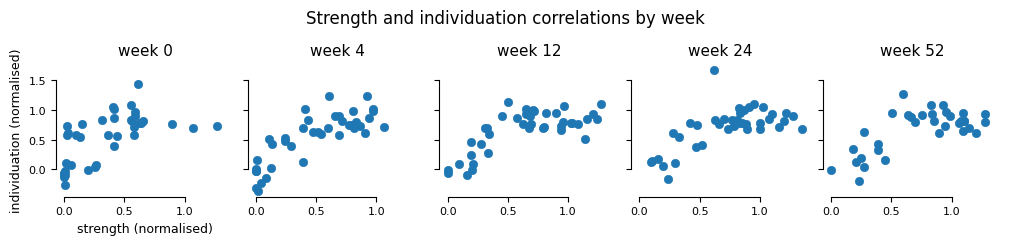

In [7]:
weeks = [0, 4, 12, 24, 52]

fig, axs = plt.subplots(1, 5, figsize = (10,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(weeks):
    ax = axs[i]
    sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav[behav.Week == week], ax = ax, edgecolor = None)
    sns.despine(trim = True)

    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_xticks([])
    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations by week", y = 1.15)
plt.show()


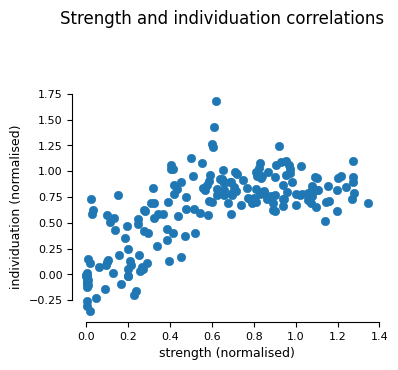

In [8]:
fig, ax = plt.subplots(figsize = (4,3))

sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav, edgecolor = None, ax = ax)
sns.despine(trim = True)


ax.set_ylabel("individuation (normalised)")
ax.set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations", y = 1.15)
plt.show()
